# 🧠 Neuro-Adaptive Book & Learning App Recommender for Children with ASD

**Hackathon:** Bluechips × Data Science Nigeria  
**Authors:** Taiye Janet Fagbolade | Iyanu Arowosola  
**Date:** 2026  

---

## Overview

This notebook builds an end-to-end **Neuro-Adaptive Learning Recommendation System** for toddlers (12–36 months) showing early signs of Autism Spectrum Disorder (ASD).

### Pipeline
```
Raw Data  →  ML Model (ASD Risk Screening)  →  Behavioral Profile  →  NLP Matcher  →  Personalized Recommendations
```

### Notebook Structure
| # | Section | Description |
|---|---------|-------------|
| 1 | Data Loading & EDA | Load the Toddler ASD screening dataset and explore it |
| 2 | Preprocessing | Clean features, encode categoricals, validate for model readiness |
| 3 | Model Training | Train XGBoost classifier with cross-validation and hyperparameter search |
| 4 | Evaluation & Explainability | Accuracy, confusion matrix, feature importance |
| 5 | App Data Pipeline | Scrape live educational apps from the Play Store |
| 6 | Recommendation Engine | TF-IDF + Cosine Similarity matching to child's behavioral profile |
| 7 | End-to-End Demo | Full pipeline run on a sample toddler profile |
| 8 | Save Artifacts | Persist model + metadata for the Streamlit app & FastAPI service |

> ⚠️ **Disclaimer:** This tool is a **screening aid only** and does not constitute a medical diagnosis. Always consult a licensed developmental pediatrician.


---
## 0. Environment Setup

Install all required dependencies. Run this cell once on a fresh environment.

In [1]:
# Install dependencies (uncomment if running for the first time)
# !pip install kagglehub pandas numpy xgboost scikit-learn matplotlib seaborn joblib google-play-scraper

In [2]:
# !pip install xgboost
# !pip install kagglehub google-play-scraper

In [3]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import os
import json
import warnings
import joblib

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import kagglehub

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ─────────────────────────────────────────────────────────
import xgboost as xgb
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import LabelEncoder

# ── NLP ──────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── App Scraper ───────────────────────────────────────────────────────────────
from google_play_scraper import search, app as play_app

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1. Data Loading & Exploratory Data Analysis

We use the **Toddler Autism Spectrum Disorder Screening** dataset from Kaggle.  
It contains responses to the **Q-CHAT-10** — a validated 10-question screening tool for toddlers aged 12–36 months — along with basic demographic fields and a final ASD classification label.

| Feature | Description |
|---------|-------------|
| A1–A10 | Binary responses to Q-CHAT-10 behavioral questions (0 = typical, 1 = delayed) |
| Age_Mons | Child's age in months |
| Sex | Biological sex |
| Class/ASD Traits | **Target** — whether the child shows ASD traits (Yes/No) |

In [4]:
print("Downloading dataset from Kaggle...")

try:
    path = kagglehub.dataset_download("fabdelja/autism-screening-for-toddlers")
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded dataset folder.")

    exact_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(exact_file_path)
    print(f"✅ Dataset loaded: {csv_files[0]}")
    print(f"   Shape: {df.shape[0]} toddlers × {df.shape[1]} features\n")

except Exception as e:
    print(f"❌ Dataset download failed: {e}")
    raise

✅ Dataset loaded: Autism_Screening_Data_Combined.csv
   Shape: 6075 toddlers × 15 features



In [5]:
# ── Quick look at the raw data ────────────────────────────────────────────────
print("First 5 Rows")
display(df.head())

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types & Non-Null Counts")
print(df.info())

First 5 Rows


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jauundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES



Column Names
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class']

Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6075 entries, 0 to 6074
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          6075 non-null   int64 
 1   A2          6075 non-null   int64 
 2   A3          6075 non-null   int64 
 3   A4          6075 non-null   int64 
 4   A5          6075 non-null   int64 
 5   A6          6075 non-null   int64 
 6   A7          6075 non-null   int64 
 7   A8          6075 non-null   int64 
 8   A9          6075 non-null   int64 
 9   A10         6075 non-null   int64 
 10  Age         6075 non-null   int64 
 11  Sex         6075 non-null   object
 12  Jauundice   6075 non-null   object
 13  Family_ASD  6075 non-null   object
 14  Class       6075 non-null   object
dtypes: int64(11), object(4)
memory usage: 712.0+ KB
None

In [7]:
# ── Missing values ────────────────────────────────────────────────────────────
# missing = df.isnull().sum()
# missing

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ No missing values detected.")
else:
    print("⚠️ Missing Values Found:")
    display(missing_df)

✅ No missing values detected.


Target column identified: 'Class'

Class Distribution:
Class
NO     4271
YES    1804


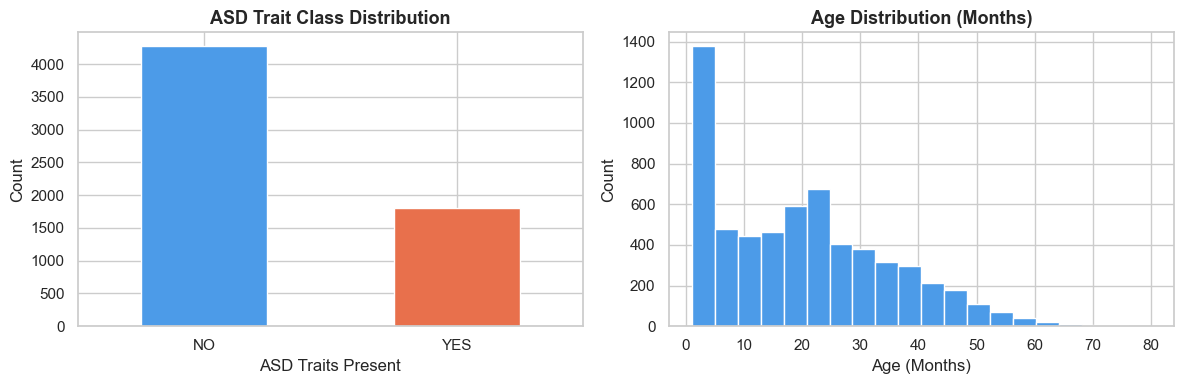

Figure saved as eda_overview.png


In [9]:
# ── Class distribution ────────────────────────────────────────────────────────
# Identify the target column dynamically but with a clear fallback
TARGET_COL = next(
    (col for col in df.columns if 'Class' in col or 'ASD Traits' in col),
    df.columns[-1]  # fallback: last column
)
print(f"Target column identified: '{TARGET_COL}'")

class_counts = df[TARGET_COL].value_counts()
print(f"\nClass Distribution:\n{class_counts.to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['#4C9BE8', '#E8704C'], edgecolor='white')
axes[0].set_title('ASD Trait Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('ASD Traits Present')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Age distribution
df['Age'].hist(bins=20, ax=axes[1], color='#4C9BE8', edgecolor='white')
axes[1].set_title('Age Distribution (Months)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (Months)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as eda_overview.png")

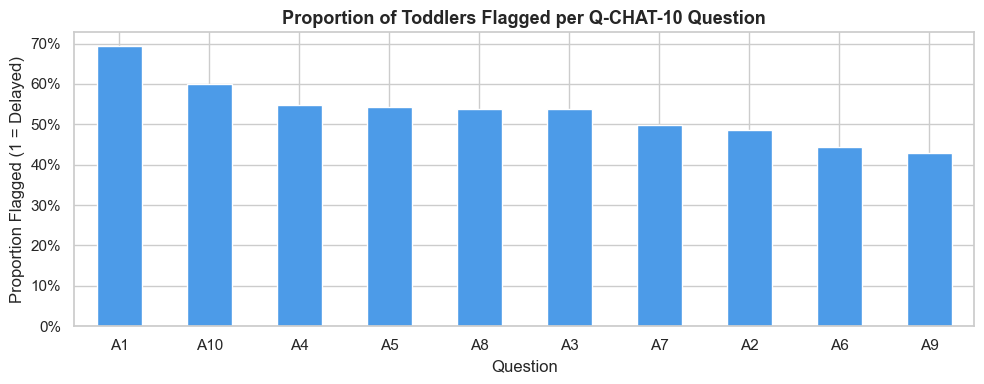

In [10]:
# ── Q-CHAT-10 response breakdown ──────────────────────────────────────────────
# How often is each behavioral question flagged (score = 1)?
question_cols = [col for col in df.columns if col.startswith('A') and col[1:].isdigit()]
question_flags = df[question_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
question_flags.plot(kind='bar', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Proportion of Toddlers Flagged per Q-CHAT-10 Question', fontsize=13, fontweight='bold')
ax.set_xlabel('Question')
ax.set_ylabel('Proportion Flagged (1 = Delayed)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('qchat_flags.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Preprocessing

Steps:
1. Encode the target variable (`Yes/No` → `1/0`)
2. Encode the `Sex` feature (`Male/Female` → `1/0`)
3. Select the feature set used for training
4. Validate there are no unexpected nulls before splitting

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6075 entries, 0 to 6074
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          6075 non-null   int64 
 1   A2          6075 non-null   int64 
 2   A3          6075 non-null   int64 
 3   A4          6075 non-null   int64 
 4   A5          6075 non-null   int64 
 5   A6          6075 non-null   int64 
 6   A7          6075 non-null   int64 
 7   A8          6075 non-null   int64 
 8   A9          6075 non-null   int64 
 9   A10         6075 non-null   int64 
 10  Age         6075 non-null   int64 
 11  Sex         6075 non-null   int64 
 12  Jauundice   6075 non-null   object
 13  Family_ASD  6075 non-null   object
 14  Class       6075 non-null   object
 15  Target      6075 non-null   int64 
dtypes: int64(13), object(3)
memory usage: 759.5+ KB


In [20]:
# ── 1. Encode target ──────────────────────────────────────────────────────────
if df[TARGET_COL].dtype == 'object':
    df['Target'] = df[TARGET_COL].str.strip().str.lower().map({'yes': 1, 'no': 0})
else:
    df['Target'] = df[TARGET_COL].astype(int)

assert df['Target'].isna().sum() == 0, "Unmapped values in Target column — check raw labels."
print(f"Target encoded. Positive rate: {df['Target'].mean():.1%}")

# # ── 2. Sex ─────────────────────────────────────────────────────────────
if 'Sex' in df.columns:
    # Just make sure it's numeric and clean
    df['Sex'] = df['Sex'].astype(int)
    
    print(f"Sex column is already encoded.")
    print(f"Male proportion: {df['Sex'].mean():.1%}")
    print(f"Unique values: {df['Sex'].unique()}")

# ── 3. Define FEATURE_COLS (single source of truth) ──────────────────────────
# These exact columns must match what the Streamlit app sends to predict_proba
BEHAVIOURAL_COLS = [col for col in df.columns if col.startswith('A') and col[1:].isdigit()]
FEATURE_COLS = BEHAVIOURAL_COLS.copy()

# Conditionally add Sex (but NOT Age_Mons — it is not collected in the app UI)
if 'Sex' in df.columns:
    FEATURE_COLS.append('Sex')

print(f"\nFinal feature set ({len(FEATURE_COLS)} features): {FEATURE_COLS}")

# ── 4. Validate ───────────────────────────────────────────────────────────────
X = df[FEATURE_COLS].copy()
y = df['Target'].copy()

assert X.isnull().sum().sum() == 0, "Null values remain in X — inspect the dataset."
print(f"\n✅ X shape: {X.shape}, y shape: {y.shape}")
print(f"  Class balance — ASD: {y.sum()} | No ASD: {(y==0).sum()}")

Target encoded. Positive rate: 29.7%
Sex column is already encoded.
Male proportion: 57.7%
Unique values: [1 0]

Final feature set (11 features): ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Sex']

✅ X shape: (6075, 11), y shape: (6075,)
  Class balance — ASD: 1804 | No ASD: 4271


---
## 3. Model Training

We use **XGBoost** — well suited for small, tabular, binary classification tasks.

Training approach:
- **Stratified K-Fold cross-validation (5 folds)** to get a robust accuracy estimate
- **RandomizedSearchCV** over key hyperparameters to improve beyond defaults
- Final evaluation on a held-out 20% test set

In [21]:
# ── Train / Test Split ────────────────────────────────────────────────────────
# Stratify ensures both splits have the same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")
print(f"Train positive rate: {y_train.mean():.1%} | Test positive rate: {y_test.mean():.1%}")

Train: 4860 samples | Test: 1215 samples
Train positive rate: 29.7% | Test positive rate: 29.7%


In [22]:
# ── Baseline: 5-Fold Stratified Cross-Validation ──────────────────────────────
print("Running 5-Fold Stratified CV on baseline XGBoost...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"\nBaseline CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores: {[f'{s:.4f}' for s in cv_scores]}")

Running 5-Fold Stratified CV on baseline XGBoost...

Baseline CV Accuracy: 0.9323 ± 0.0027
Per-fold scores: ['0.9342', '0.9352', '0.9342', '0.9290', '0.9290']


In [23]:
# ── Hyperparameter Search ─────────────────────────────────────────────────────
# RandomizedSearchCV is faster than GridSearch and works well on small datasets.
param_grid = {
    'n_estimators':    [50, 100, 200, 300],
    'max_depth':       [3, 4, 5, 6],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5],
}

print("Running RandomizedSearchCV (this may take ~1-2 minutes)...")

search_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
random_search = RandomizedSearchCV(
    search_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='accuracy',
    cv=cv,
    verbose=0,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)

print(f"\n✅ Best CV Accuracy:  {random_search.best_score_:.4f}")
print(f"   Best Parameters:  {random_search.best_params_}")

asd_model = random_search.best_estimator_

Running RandomizedSearchCV (this may take ~1-2 minutes)...

✅ Best CV Accuracy:  0.9393
   Best Parameters:  {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


---
## 4. Evaluation & Explainability

We evaluate on the held-out test set and examine **feature importance** so clinicians and judges can understand what the model is relying on.

In [24]:
# ── Test Set Performance ──────────────────────────────────────────────────────
y_pred  = asd_model.predict(X_test)
y_proba = asd_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_auc      = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("         TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  ROC-AUC  : {test_auc:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No ASD', 'ASD']))

         TEST SET RESULTS
  Accuracy : 0.9259  (92.59%)
  ROC-AUC  : 0.9650

Detailed Classification Report:
              precision    recall  f1-score   support

      No ASD       0.98      0.92      0.95       854
         ASD       0.83      0.94      0.88       361

    accuracy                           0.93      1215
   macro avg       0.90      0.93      0.91      1215
weighted avg       0.93      0.93      0.93      1215



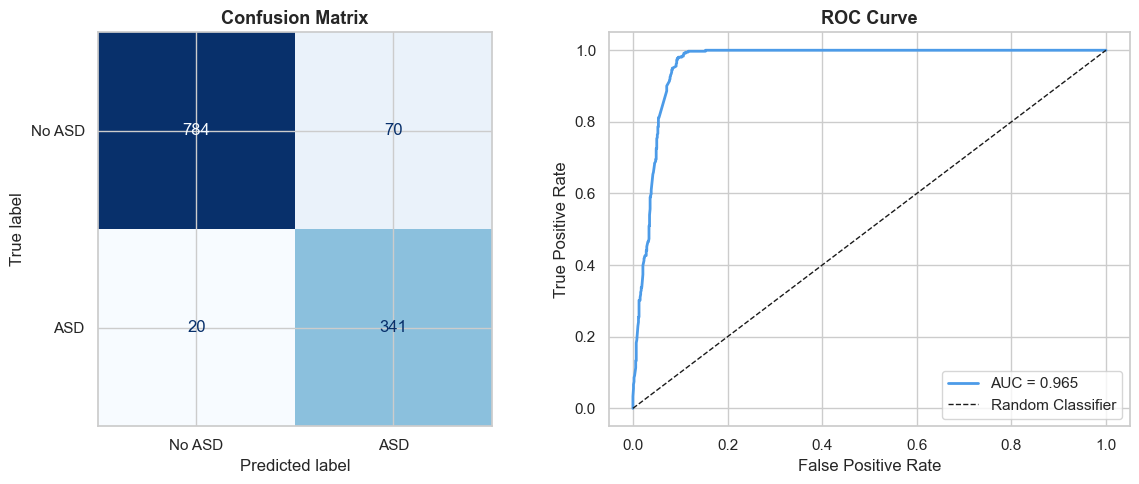

Figure saved as evaluation_plots.png


In [25]:
# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No ASD', 'ASD'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#4C9BE8', lw=2, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as evaluation_plots.png")

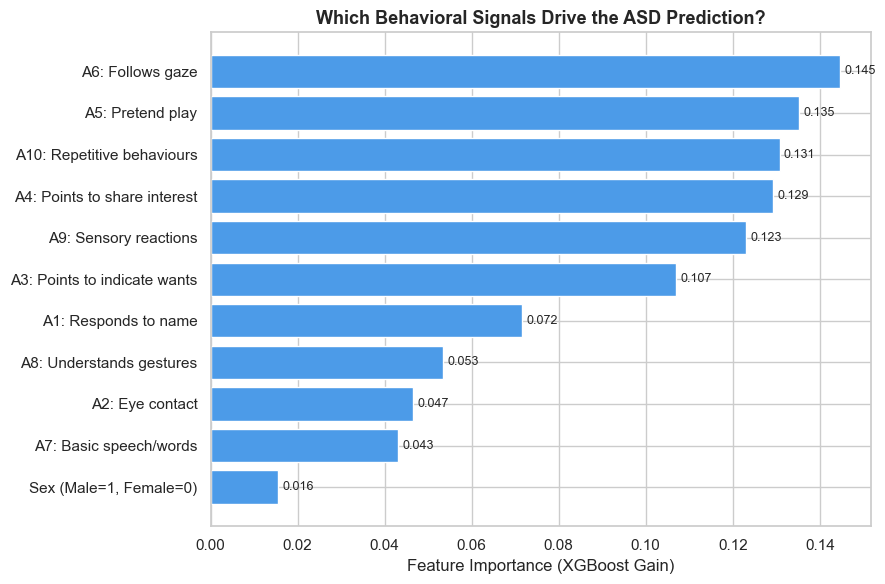

Figure saved as feature_importance.png


In [26]:
# ── Feature Importance ────────────────────────────────────────────────────────
# XGBoost gain importance: how much each feature contributes to splits.
# This is the most meaningful importance metric for this use case.
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': asd_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Map question codes to human-readable labels
QUESTION_LABELS = {
    'A1':  'A1: Responds to name',
    'A2':  'A2: Eye contact',
    'A3':  'A3: Points to indicate wants',
    'A4':  'A4: Points to share interest',
    'A5':  'A5: Pretend play',
    'A6':  'A6: Follows gaze',
    'A7':  'A7: Basic speech/words',
    'A8':  'A8: Understands gestures',
    'A9':  'A9: Sensory reactions',
    'A10': 'A10: Repetitive behaviours',
    'Sex': 'Sex (Male=1, Female=0)',
}
importance_df['Label'] = importance_df['Feature'].map(QUESTION_LABELS)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Label'], importance_df['Importance'],
               color='#4C9BE8', edgecolor='white')
ax.set_xlabel('Feature Importance (XGBoost Gain)')
ax.set_title('Which Behavioral Signals Drive the ASD Prediction?',
             fontsize=13, fontweight='bold')

# Annotate bars
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as feature_importance.png")

---
## 5. App Data Pipeline

We scrape the **Google Play Store** for live educational and therapy apps relevant to ASD.  
The scraped data is cached to disk as `app_cache.json` so the Streamlit app doesn't need to re-scrape on every run (avoids rate-limiting and crashes).

> **Note:** A static fallback CSV is included so the recommendation engine still works if the scraper fails during a live demo.

In [27]:
# ── Configuration ─────────────────────────────────────────────────────────────
SCRAPE_QUERIES    = [
    "autism speech therapy special education",
    "autism learning toddler app",
    "speech delay communication therapy child",
]
SCRAPE_TOP_N      = 10   # top results per query
VALID_GENRES      = {'Education', 'Medical', 'Parenting', 'Health & Fitness'}
CACHE_PATH        = 'app_cache.json'

# ── Fallback static apps ──────────────────────────────────────────────────────
# If scraping fails (network, rate limit, CI environment), we fall back to these.
FALLBACK_APPS = [
    {
        'App_Name': 'Autism iHelp – Listen',
        'Category': 'Education',
        'Rating': 4.3,
        'Price': 'Paid',
        'Description': 'Designed for children with autism and speech delay. Builds listening comprehension, receptive language, and following directions through visual and auditory cues.'
    },
    {
        'App_Name': 'Proloquo2Go',
        'Category': 'Medical',
        'Rating': 4.5,
        'Price': 'Paid',
        'Description': 'AAC (Augmentative and Alternative Communication) app for non-verbal children and those with speech delays. Uses symbols and words to build expressive language.'
    },
    {
        'App_Name': 'Endless Alphabet',
        'Category': 'Education',
        'Rating': 4.7,
        'Price': 'Free',
        'Description': 'Vocabulary and language learning app for young children. Engaging puzzles support early word recognition, social-emotional learning, and communication skills.'
    },
    {
        'App_Name': 'Otsimo Special Education',
        'Category': 'Education',
        'Rating': 4.6,
        'Price': 'Free',
        'Description': 'Special education app for children with autism, Down syndrome, and developmental delays. Covers speech, cognitive skills, social interaction, and daily living activities.'
    },
    {
        'App_Name': 'Autism & PDD – Reasoning',
        'Category': 'Education',
        'Rating': 4.1,
        'Price': 'Paid',
        'Description': 'Targets reasoning skills, following instructions, and social cognitive understanding for children with autism spectrum disorder. Includes sensory-friendly visual exercises.'
    },
    {
        'App_Name': 'Lingokids',
        'Category': 'Education',
        'Rating': 4.5,
        'Price': 'Free',
        'Description': 'Early childhood learning app with songs, games and interactive stories. Supports speech development, vocabulary acquisition, and social skill building for young learners.'
    },
]

print(f"Scrape config ready. Fallback dataset has {len(FALLBACK_APPS)} apps.")

Scrape config ready. Fallback dataset has 6 apps.


In [29]:
def scrape_play_store(queries, top_n, valid_genres):
    """
    Search the Google Play Store across multiple queries and return
    a deduplicated list of app dicts filtered to valid genres.
    """
    seen_ids  = set()
    app_data  = []

    for query in queries:
        print(f"  Searching: '{query}'")
        try:
            results = search(query, lang='en', country='us')[:top_n]
        except Exception as e:
            print(f"    ⚠️  Search failed: {e}")
            continue

        for result in results:
            pkg_id = result['appId']
            if pkg_id in seen_ids:
                continue
            seen_ids.add(pkg_id)

            try:
                details = play_app(pkg_id, lang='en', country='us')
                if details.get('genre') not in valid_genres:
                    continue
                app_data.append({
                    'App_Name':    details['title'],
                    'Category':    details['genre'],
                    'Rating':      round(details.get('score', 0), 2),
                    'Price':       'Free' if details.get('free') else 'Paid',
                    'Description': (details.get('description') or '')[:600],
                })
                print(f"    ✅ {details['title']}")
            except Exception as e:
                print(f"    ❌ Failed for {pkg_id}: {e}")

    return app_data


# ── Run scraper or load cache ─────────────────────────────────────────────────
if os.path.exists(CACHE_PATH):
    print(f"Cache found at '{CACHE_PATH}'. Loading cached app data...")
    with open(CACHE_PATH, 'r') as f:
        app_data_raw = json.load(f)
    print(f"✅ Loaded {len(app_data_raw)} apps from cache.")
else:
    print("No cache found. Scraping Play Store (this may take ~60 seconds)...")
    app_data_raw = scrape_play_store(SCRAPE_QUERIES, SCRAPE_TOP_N, VALID_GENRES)

    if app_data_raw:
        with open(CACHE_PATH, 'w') as f:
            json.dump(app_data_raw, f, indent=2)
        print(f"\n✅ Scraped {len(app_data_raw)} apps. Saved to '{CACHE_PATH}'.")
    else:
        print("\n⚠️  Scraping returned no results. Using fallback dataset.")
        app_data_raw = FALLBACK_APPS

df_apps = pd.DataFrame(app_data_raw)
print(f"\nApp database shape: {df_apps.shape}")
display(df_apps[['App_Name','Category','Rating','Price']].head(10))

Cache found at 'app_cache.json'. Loading cached app data...
✅ Loaded 9 apps from cache.

App database shape: (9, 5)


,App_Name,Category,Rating,Price
0,Autism Speech and Language,Parenting,4.02,Free
1,BASICS: Speech | Autism | ADHD,Education,3.94,Free
2,Speech Blubs: Language Therapy,Parenting,4.46,Free
3,Language Therapy for Children,Education,4.64,Free
4,Autism Soundboard,Education,0.00,Free
5,SpeakEasy: Home Speech Therapy,Parenting,3.64,Free
6,Autism 360: Parenting,Parenting,3.35,Free
7,Speech Therapy: Let Me Talk,Education,4.14,Free
8,Leeloo AAC - Autism Speech App,Parenting,3.78,Free


---
## 6. Recommendation Engine

The engine translates a child's **behavioral profile** (their A1–A10 scores) into a natural-language query, then uses **TF-IDF + Cosine Similarity** to find the best-matching apps from our database.

### Behavioral Signal → Need Mapping

| Questions Flagged | Inferred Need Tag |
|-------------------|-----------------------|
| A1, A7 | Speech delay, non-verbal communication |
| A2, A6, A8 | Eye contact, joint attention, gesture understanding |
| A3, A4, A5 | Social interaction, play, cognitive learning |
| A9, A10 | Sensory regulation, routine, repetitive behaviour |

In [30]:
# ── Need-Mapping Logic ────────────────────────────────────────────────────────
# All 10 questions are now covered (original code missed A2, A5, A6, A8)
NEED_MAPPING = {
    # Tuple of question column names → semantic need text
    ('A1', 'A7'):       'speech delay non-verbal communication words language talk',
    ('A2', 'A6', 'A8'): 'eye contact joint attention gesture social awareness',
    ('A3', 'A4', 'A5'): 'social interaction play cognitive learning pretend',
    ('A9', 'A10'):      'sensory processing meltdowns routine calm repetitive behaviour visual',
}


def build_toddler_profile_text(row: pd.Series) -> str:
    """
    Convert a row of binary A1-A10 scores into a semantic
    need-description string suitable for TF-IDF matching.

    Parameters
    ----------
    row : pd.Series  —  must contain columns A1..A10 with values 0/1

    Returns
    -------
    str  —  space-joined need phrases; 'autism special education' as fallback
    """
    needs = []
    for question_group, need_text in NEED_MAPPING.items():
        # If ANY question in the group is flagged (=1), add the need
        if any(row.get(q, 0) == 1 for q in question_group):
            needs.append(need_text)
    return ' '.join(needs) if needs else 'autism special education cognitive skills'


def recommend_apps(toddler_df: pd.DataFrame, df_apps: pd.DataFrame,
                   top_n: int = 3) -> pd.DataFrame:
    """
    Given a single-row DataFrame of toddler behavioral scores,
    return the top_n most relevant apps ranked by TF-IDF cosine similarity.

    Parameters
    ----------
    toddler_df : pd.DataFrame  — single row with A1..A10 (and optionally Sex)
    df_apps    : pd.DataFrame  — app database with 'Description' column
    top_n      : int           — number of recommendations to return

    Returns
    -------
    pd.DataFrame with columns: App_Name, Category, Rating, Price, Match_Score_%
    """
    profile_text = build_toddler_profile_text(toddler_df.iloc[0])

    descriptions = df_apps['Description'].fillna('').tolist()
    tfidf        = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(descriptions)
    query_vector = tfidf.transform([profile_text])

    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    result = df_apps.copy()
    result['Match_Score_%'] = (scores * 100).round(1)
    return (
        result
        .sort_values('Match_Score_%', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


print("✅ Recommendation engine defined.")
print(f"   NEED_MAPPING covers {sum(len(k) for k in NEED_MAPPING)} / 10 Q-CHAT questions")

✅ Recommendation engine defined.
   NEED_MAPPING covers 10 / 10 Q-CHAT questions


---
## 7. End-to-End Demo

We run two test profiles through the full pipeline:
- **Profile A:** Moderate delays (mixed flags)
- **Profile B:** Severe delays (all flags set)

In [32]:
def run_pipeline(profile_dict: dict, label: str = 'Toddler') -> None:
    """
    Run the full ASD screening + recommendation pipeline on a single profile.

    Parameters
    ----------
    profile_dict : dict  — keys must match FEATURE_COLS
    label        : str   — display name for this profile
    """
    toddler_df = pd.DataFrame([profile_dict])

    # Ensure column order matches training
    toddler_df = toddler_df[FEATURE_COLS]

    risk_pct = asd_model.predict_proba(toddler_df)[0][1] * 100

    print("=" * 58)
    print(f"  PROFILE: {label}")
    print("=" * 58)
    print(f"  ASD Trait Probability : {risk_pct:.2f}%")

    if risk_pct >= 50:
        print("  Status               : ⚠️  HIGH LIKELIHOOD — Intervention Recommended")
        print("\n  --- Top App Recommendations ---")
        recs = recommend_apps(toddler_df, df_apps, top_n=3)
        for _, row in recs.iterrows():
            print(f"\n  ⭐ {row['App_Name']} (Match: {row['Match_Score_%']}%)")
            print(f"     Category: {row['Category']} | Rating: {row['Rating']}★ | {row['Price']}")
            print(f"     {row['Description'][:120]}...")
    else:
        print("Status : ✅ LOW LIKELIHOOD — Standard monitoring advised")
    print()

In [33]:
# ── Profile A: Moderate delays ────────────────────────────────────────────────
profile_a = {
    'A1': 1, 'A2': 0, 'A3': 1, 'A4': 1, 'A5': 0,
    'A6': 1, 'A7': 1, 'A8': 0, 'A9': 1, 'A10': 1,
    'Sex': 1,
}
run_pipeline(profile_a, label="Profile A — Moderate Delays (30-month Male)")

  PROFILE: Profile A — Moderate Delays (30-month Male)
  ASD Trait Probability : 73.44%
  Status               : ⚠️  HIGH LIKELIHOOD — Intervention Recommended

  --- Top App Recommendations ---

  ⭐ SpeakEasy: Home Speech Therapy (Match: 16.1%)
     Category: Parenting | Rating: 3.64★ | Free
     <h1><b>SpeakEasy has been shown by a rigorous randomized control trial to improve parent-child communication.</b> SpeakE...

  ⭐ BASICS: Speech | Autism | ADHD (Match: 12.8%)
     Category: Education | Rating: 3.94★ | Free
     BASICS is an award-winning early learning app trusted by over 7 lakh families worldwide. Created by expert speech therap...

  ⭐ Speech Therapy: Let Me Talk (Match: 11.8%)
     Category: Education | Rating: 4.14★ | Free
     🧑👩Listening of non-speech sounds enhances a child's ability to analyze, evaluate, and think critically. Children develop...



In [35]:
# ── Profile B: Severe delays ──────────────────────────────────────────────────
profile_b = {
    'A1': 1, 'A2': 1, 'A3': 1, 'A4': 1, 'A5': 1,
    'A6': 1, 'A7': 1, 'A8': 1, 'A9': 1, 'A10': 1,
    'Sex': 1,
}
run_pipeline(profile_b, label="Profile B — Severe Delays (All Flags Set, Male)")

  PROFILE: Profile B — Severe Delays (All Flags Set, Male)
  ASD Trait Probability : 65.51%
  Status               : ⚠️  HIGH LIKELIHOOD — Intervention Recommended

  --- Top App Recommendations ---

  ⭐ SpeakEasy: Home Speech Therapy (Match: 16.1%)
     Category: Parenting | Rating: 3.64★ | Free
     <h1><b>SpeakEasy has been shown by a rigorous randomized control trial to improve parent-child communication.</b> SpeakE...

  ⭐ BASICS: Speech | Autism | ADHD (Match: 12.8%)
     Category: Education | Rating: 3.94★ | Free
     BASICS is an award-winning early learning app trusted by over 7 lakh families worldwide. Created by expert speech therap...

  ⭐ Speech Therapy: Let Me Talk (Match: 11.8%)
     Category: Education | Rating: 4.14★ | Free
     🧑👩Listening of non-speech sounds enhances a child's ability to analyze, evaluate, and think critically. Children develop...



---
## 8. Save Artifacts

We save:
1. **`asd_model.pkl`** — the trained XGBoost model
2. **`model_card.json`** — metadata about the model (features, accuracy, AUC, training date)

The model card is critical for reproducibility and for the FastAPI microservice to validate that incoming requests match the expected feature schema.

In [41]:
import datetime

# ── Save model ────────────────────────────────────────────────────────────────
MODEL_PATH = 'asd_model1.pkl'
joblib.dump(asd_model, MODEL_PATH)
print(f"✅ Model saved → '{MODEL_PATH}'")

# ── Save model card ───────────────────────────────────────────────────────────
model_card = {
    'model_type':        'XGBoostClassifier',
    'feature_columns':   FEATURE_COLS,
    'n_features':        len(FEATURE_COLS),
    'test_accuracy':     round(float(test_accuracy), 4),
    'test_roc_auc':      round(float(test_auc), 4),
    'best_params':       asd_model.get_xgb_params(),
    'training_samples':  int(len(X_train)),
    'test_samples':      int(len(X_test)),
    'positive_rate_train': round(float(y_train.mean()), 4),
    'trained_on':        datetime.datetime.utcnow().isoformat() + 'Z',
    'dataset':           'fabdelja/autism-screening-for-toddlers (Kaggle)',
    'disclaimer':        'Screening aid only. Not a medical diagnosis tool.',
}

✅ Model saved → 'asd_model1.pkl'


In [42]:

MODEL_CARD_PATH = 'model_card1.json'
with open(MODEL_CARD_PATH, 'w') as f:
    json.dump(model_card, f, indent=2)

print(f"✅ Model card saved → '{MODEL_CARD_PATH}'")
print("\n--- Model Card Summary ---")
print(json.dumps(model_card, indent=2))

✅ Model card saved → 'model_card1.json'

--- Model Card Summary ---
{
  "model_type": "XGBoostClassifier",
  "feature_columns": [
    "A1",
    "A2",
    "A3",
    "A4",
    "A5",
    "A6",
    "A7",
    "A8",
    "A9",
    "A10",
    "Sex"
  ],
  "n_features": 11,
  "test_accuracy": 0.9259,
  "test_roc_auc": 0.965,
  "best_params": {
    "objective": "binary:logistic",
    "base_score": null,
    "booster": null,
    "colsample_bylevel": null,
    "colsample_bynode": null,
    "colsample_bytree": 0.8,
    "device": null,
    "eval_metric": "logloss",
    "gamma": null,
    "grow_policy": null,
    "interaction_constraints": null,
    "learning_rate": 0.2,
    "max_bin": null,
    "max_cat_threshold": null,
    "max_cat_to_onehot": null,
    "max_delta_step": null,
    "max_depth": 4,
    "max_leaves": null,
    "min_child_weight": 5,
    "monotone_constraints": null,
    "multi_strategy": null,
    "n_jobs": null,
    "num_parallel_tree": null,
    "random_state": 42,
    "reg_alpha":

In [46]:
import platform
print(platform.python_version())

3.13.9
